<a href="https://colab.research.google.com/github/kayleendo/Project-1-Wrangling-EDA-kNN/blob/main/DS_3001_Project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Project 1

The goal of the first project is to do some wrangling, EDA, and visualization, and generate sequences of values. We will focus on:

- CDC National Health and Nutritional Examination Survey (NHANES, 1999-2000): https://wwwn.cdc.gov/nchs/nhanes/continuousnhanes/default.aspx?BeginYear=1999
- CDC Linked Mortality File (LMF, 1999-2000): https://www.cdc.gov/nchs/data-linkage/mortality-public.htm

NHANES is a rich panel dataset on health and behavior, collected bi-yearly from around 1999 to now. We will focus on the 1999 wave, because that has the largest follow-up window, providing us with the richest mortality data. The mortality data is provided by the CDC Linked Mortality File.

The purpose of the project is to use $k$-NN to predict who dies (hard or soft classification) and how long they live (regression).

### Part 1: Wrangling and EDA (40/100 pts)




1.

In [ ]:
# Download packages
import pandas as pd
import numpy as np

2.

In [ ]:
# Setup: Writing a function data directly from website to use with all of our data imports.
# This is so that our code actually runs whenever graders run it.
import requests

def load_data(url, temp_path, filetype):
    # Download the file
    response = requests.get(url)
    response.raise_for_status()

    with open(temp_path, "wb") as f:
        f.write(response.content)

    if filetype == "csv":
        return pd.read_csv(temp_path)
    elif filetype == "sas":
        return pd.read_sas(temp_path, format="xport")


# 1.) Starting off with loading DEMO.xpt (NHANES 1999-2000 from CDC  website)
gdf = load_data("https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/1999/DataFiles/DEMO.xpt",
                "/tmp/DEMO.xpt", "sas")

# 2.) Loading LMF from github
mdf = load_data("https://raw.githubusercontent.com/ds4e/undergrad_ml_assignments/refs/heads/main/data/linked_mortality_file_1999_2000.csv",
                "/tmp/linked_mortality_file_1999_2000.csv", "csv")

# Merge into one df
df = gdf.merge(mdf, on="SEQN", how="inner")
df.head(2)

,SEQN,SDDSRVYR,RIDSTATR,RIDEXMON,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDAGEEX,RIDRETH1,RIDRETH2,...,WTIREP50,WTIREP51,WTIREP52,ELIGSTAT,MORTSTAT,UCOD_LEADING,DIABETES,HYPERTEN,PERMTH_INT,PERMTH_EXM
0,1.0,1.0,2.0,2.0,2.0,2.0,29.0,31.0,4.0,2.0,...,10327.992682,9809.165049,10323.315747,2,NaN,NaN,NaN,NaN,NaN,NaN
1,2.0,1.0,2.0,2.0,1.0,77.0,926.0,926.0,3.0,1.0,...,27268.025234,27406.383620,26984.812909,1,1.0,6.0,0.0,0.0,177.0,177.0


3.

1. **ELIGSTAT** indicates mortality likage eligibility. A value of 1
indicates that the survey participant was eligible for the mortality linkage, a value of 2 indicates the survey participant was unger the age of 18 and therefore not eligible for public release, and a value of 3 indicates the survey participant was not eligible due to possessing insufficient identifying data to conduct data linkage. Because Linkage Mortality Files only include mortality information for survey participants aged 18 and older, minors will have an ELIGSTAT value of 2 and will have missing values for all other mortality or follow-up variables.
2. **MORTSTAT** refers to the determination of vital status. It is the mortality status at the end of follow-up for survey participants who are linkage eligible. Each survey participants eligible is assigned a vital status code (0= assumed alive, 1= assumed deceased). Vital status can be identified by crossing MORTSTAT
and the leading cause of death variable, UCOD_LEADING. However, in a small number of cases UCOD_LEADING was also missing from the death
certificate record. For participants who are not linkage eligible, MORTSTAT is coded as a
numeric missing value.
3. **PERMTH_INT** indicates the follow-up time that has been calculated using person
months from the date of interview to the date of death or the end of the mortality period (for 1999-2018 NHANES and NHANES III).  
4. **RIDAGEEX** indicates the survey participant's age at the time of their medical examination in years. It is a continous numeric variable.

4.

We downloaded Body Measures (BMX), Blood Pressure (BPX), Smoking (SMQ), and Cholesterol (LAB13). These variables were selected because they represent known mortality risk factors. Age, smoking, obesity, and cholesterol levels are all strongly associated with mortality.

In [ ]:
# 1.) Loading BMX data
bmx = load_data ("https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/1999/DataFiles/BMX.xpt", "/tmp/BMX.xpt", "sas")

# 2.) Loading BPX data
bpx = load_data ("https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/1999/DataFiles/BPX.xpt", "/tmp/BPX.xpt", "sas")

# 3.) Loading SMQ data
smq = load_data ("https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/1999/DataFiles/SMQ.xpt", "/tmp/SMQ.xpt","sas")

# 4.) Loading LAB13 data
lab = load_data ("https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/1999/DataFiles/LAB13.xpt", "/tmp/LAB13.xpt", "sas")

In [ ]:
# Combine the datasets into one complete dataframe
mortality = gdf.merge(mdf, on="SEQN", how="inner")
mortality = mortality.merge(bmx, on="SEQN", how="left")
mortality = mortality.merge(smq, on="SEQN", how="left")
mortality = mortality.merge(bpx, on="SEQN", how="left")
mortality = mortality.merge(lab, on="SEQN", how="left")

In [ ]:
# Document the missing values
mortality.isna().sum().sort_values(ascending=False)

,0
BMAUPREL,9965
BMAUPLEL,9965
BMIHEAD,9964
BMALLKNE,9964
DMARACE,9963
...,...
WTMEC4YR,0
SDDSRVYR,0
SDMVSTRA,0
SDJ1REPN,0


5.

### Part 2: $k$-NN classification/regression, write-up (50/100 pts)

Submit a notebook that clearly addresses the following, using code and markdown chunks:

1. Describe the data, particularly what an observation is and whether there are any missing data that might impact your analysis. Who collected the data and why? What known limitations are there to analysis? (10/100 pts)
2. Describe the variables you selected to predict mortality and life expectancy, and the rationale behind them. Analyze your variables using describe tables, kernel densities, scatter plots, and conditional kernel densities. Are there any patterns of interest to notice? (10/100 pts)
3. Using your variables to predict mortality using a $k$-Nearest Neighbor Classifier. Analyze its performance and explain clearly how you select $k$. (10/100 pts)
4. Using your variables to predict life expectancy using a $k$-Nearest Neighbor Regressor. Analyze its performance and explain clearly how you select $k$. (10/100 pts)
5. Describe how your model could be used for health interventions based on patient characteristics. Are there any limitations or risks to consider? (10/100 pts)

## Submission (10/100 pts)

Submit your work in a well-organized GitHub repo, where the code is appropriately commented and all members of the group have made significant contributions to the commit history. (10/100 pts)

1. This data set includes information from the National Health and Nutrition Examination Survey (NHANES) and stores background, socioeconomic, and medical information about individuals who completed household interviews between 1999 and 2000. It contains individual-level information such as age, gender, race/ethnicity, and country of birth. The data set also includes household and family-level information such as household size and total family income. Medical information, such as body measures, blood pressure, smoking habits, and cholesterol, is only stored for individuals with sufficient identifying data or individuals over the age of 18.

Each row represents an observation of an individual who completed the household interview. Each observation has a unique data release number (SDDSRVYR), and all variable data in the row describes that one individual.

Missing data for individuals limits or data analysis to adults, as many key variables are not displayed for minors. This means our results will only apply to adult populations. Additional, many observations are missing a mortality status. Without a known mortality outcome, we are unable to include those individuals in our analyses. This makes these rows unusable, and reduces our sample size.

This data was collected by the NHANES, which is conduted by the National Center for Health Statistics (NCHS), and is a part of the Centers for Disease Control and Prevention (CDC). The NHAHES is a nationally representative survey of the US population, and is used to asses the health and well being of the population. The CDC uses these results to monitor health trends and to track disparities across different demographic groups.



2. We selected Age (RIDAGEYR), Body Mass Index (BMXBMI), Total Cholesterol (LBXTC), and Smoking Status (SMQ020) to predict our target, Mortality Status (MORTSTAT). These specific variables were selected because they represent well-known mortality risk factors and are all strongly associated with life expectancy. From the describe table, we found that there is a lot of missing data for most columns, to address this, we found the average of each row and replaced missing data with that value, additionally, there are some significant outliers for BMI , Cholesterol, and also a 9 value for Smoking, which doesn't make sense since it should either be 1 or 2. The Kernel density plot shows that the ages aren't evenly distributed across ages, heavily weighted towards younger population. From the scatterplot, we see a very weak positive correlation betweeen age and cholesterol. From the condition kernal density plot, there is a small tendency towards a higher bmi from deceased individuals.

In [ ]:
# Define your list of variables
var_list = ['MORTSTAT', 'RIDAGEYR', 'BMXBMI', 'LBXTC', 'SMQ020']

# Create the smaller dataframe
mortality_small = mortality.loc[:, var_list]

          MORTSTAT      RIDAGEYR       BMXBMI        LBXTC       SMQ020
count  5445.000000  9.965000e+03  8462.000000  7429.000000  4877.000000
mean      0.307622  2.972885e+01    24.894254   186.956253     1.544187
std       0.461551  2.483034e+01     7.061759    42.876045     0.603811
min       0.000000  5.397605e-79    11.490000    72.000000     1.000000
25%       0.000000  1.100000e+01    19.660000   156.000000     1.000000
50%       0.000000  1.900000e+01    24.160000   182.000000     2.000000
75%       1.000000  4.800000e+01    29.007500   213.000000     2.000000
max       1.000000  8.500000e+01    66.440000   575.000000     9.000000


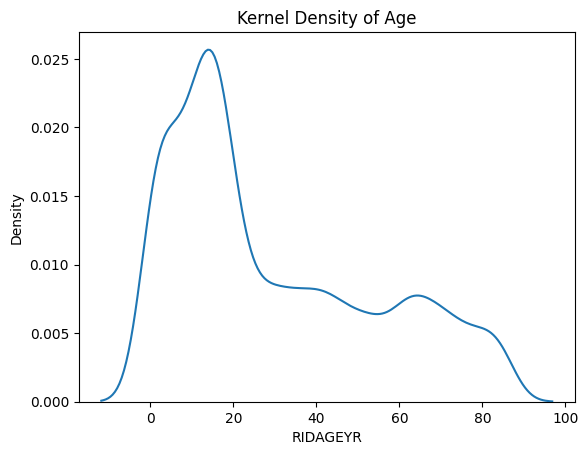

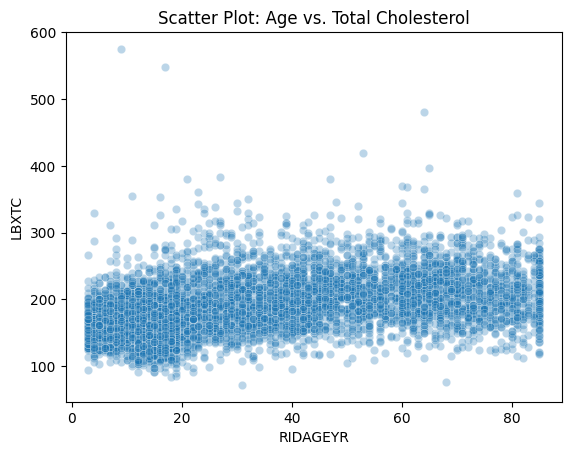

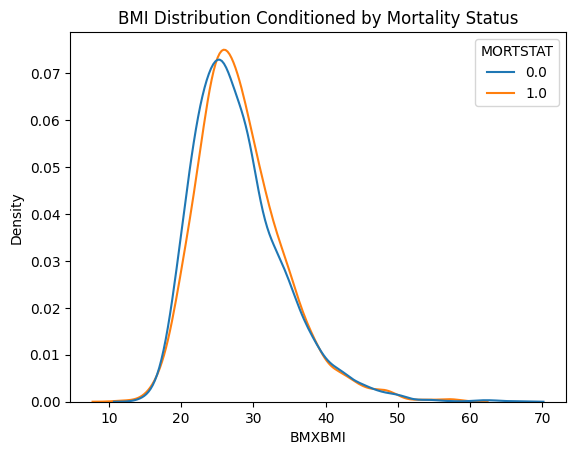

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Describe Table:
print(mortality_small.describe())

# Kernel Density: Shows the smooth distribution of age
sns.kdeplot(data=mortality_small, x='RIDAGEYR')
plt.title("Kernel Density of Age")
plt.show()

# Scatter Plot: Shows how relationship between age and total cholesterol
sns.scatterplot(data=mortality_small, x='RIDAGEYR', y='LBXTC', alpha=0.3)
plt.title("Scatter Plot: Age vs. Total Cholesterol")
plt.show()

# Conditional Kernel Density: Shows a BMI seperated by Morality Status
sns.kdeplot(data=mortality_small, x='BMXBMI', hue='MORTSTAT', common_norm=False)
plt.title("BMI Distribution Conditioned by Mortality Status")
plt.show()

In [ ]:
# Replace the missing (NaN) values with that average
mortality_small['BMXBMI'] = mortality_small['BMXBMI'].fillna(mortality_small['BMXBMI'].mean())
mortality_small['LBXTC'] = mortality_small['LBXTC'].fillna(mortality_small['LBXTC'].mean())
mortality_small['SMQ020'] = mortality_small['SMQ020'].fillna(mortality_small['SMQ020'].mean())

# Drop any row that has missing data
mortality_clean = mortality_small.dropna().copy()

print(mortality_clean.describe())



          MORTSTAT     RIDAGEYR       BMXBMI        LBXTC       SMQ020
count  5445.000000  5445.000000  5445.000000  5445.000000  5445.000000
mean      0.307622    47.201102    27.734426   199.018867     1.544303
std       0.461551    20.685874     6.021283    39.471469     0.571315
min       0.000000    18.000000    12.040000    72.000000     1.000000
25%       0.000000    29.000000    24.060000   177.000000     1.000000
50%       0.000000    45.000000    26.240000   189.000000     1.544187
75%       1.000000    65.000000    30.670000   222.000000     2.000000
max       1.000000    85.000000    66.440000   480.000000     9.000000


In [ ]:
import numpy as np

# Drop extreme BMI outliers (keep the bottom 99%)
q99_bmi = np.quantile(mortality_clean['BMXBMI'], .99)
keep_bmi = mortality_clean['BMXBMI'] < q99_bmi
mortality_clean = mortality_clean.loc[keep_bmi, :]

# Drop extreme Cholesterol outliers (keep the bottom 99%)
q99_chol = np.quantile(mortality_clean['LBXTC'], .99)
keep_chol = mortality_clean['LBXTC'] < q99_chol
mortality_clean = mortality_clean.loc[keep_chol, :]

# Keep rows where smoking is exactly 1 OR 2
keep_smoking = (mortality_clean['SMQ020'] == 1) | (mortality_clean['SMQ020'] == 2)
mortality_clean = mortality_clean.loc[keep_smoking, :]

mortality_clean.describe()

,MORTSTAT,RIDAGEYR,BMXBMI,LBXTC,SMQ020
count,4750.000000,4750.000000,4750.000000,4750.000000,4750.000000
mean,0.339368,50.572842,27.757078,200.857065,1.525053
std,0.473545,19.274110,5.485710,35.888373,0.499425
min,0.000000,20.000000,12.040000,72.000000,1.000000
25%,0.000000,34.000000,24.410000,181.000000,1.000000
50%,0.000000,49.000000,26.450000,192.000000,2.000000
75%,1.000000,67.000000,30.730000,224.000000,2.000000
max,1.000000,85.000000,47.320000,312.000000,2.000000


3. We used a k-Nearest Neighbor (kNN) classifier to predict mortality (MORTSTAT) from age (RIDAGEYR), BMI (BMXBMI), total cholesterol (LBXTC), and smoking status (SMQ020). All features were scaled to 0–1 using a Min-Max scaler. The data were split into 80% training and 20% test sets. To select the optimal number of neighbors (k), we tested odd values from 3 to 301 and measured training and test accuracy. Small k values overfit the training data, while large k values underfit. Test accuracy peaked around k ≈ 35–65 with a maximum accuracy of approximately 0.747, which we selected as the best k. This demonstrates the bias-variance tradeoff and provides the model with the best performance on unseen data.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Define X and y
X = mortality_clean[['RIDAGEYR', 'BMXBMI', 'LBXTC', 'SMQ020']]
y = mortality_clean['MORTSTAT']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Scale Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define k values to test
k_grid = np.array([ (2*k+3) for k in range(0,150) ])  # 3, 5, 7, ..., 301

train_accuracies = []
test_accuracies = []

# Loop through k values
for k in k_grid:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)

    train_acc = model.score(X_train_scaled, y_train)
    test_acc = model.score(X_test_scaled, y_test)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    print(f'k={k}: Train Acc={train_acc:.3f}, Test Acc={test_acc:.3f}')

# Plot training vs test accuracy
plt.figure(figsize=(12,6))
sns.lineplot(x=k_grid, y=train_accuracies, label='Training Accuracy')
sns.lineplot(x=k_grid, y=test_accuracies, label='Test Accuracy')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.title('kNN Training vs Test Accuracy')
plt.show()

# Find optimal k
test_accuracies = np.array(test_accuracies)
optimal_indices = np.where(test_accuracies == np.max(test_accuracies))
k_optimal = k_grid[optimal_indices]

print(f"Optimal k value(s): {k_optimal}")
print(f"Maximum test accuracy: {test_accuracies[optimal_indices][0]:.3f}")
